# Data Preprocessing

In [96]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

## Building a Table for the Dataset

In [17]:

def build_table(folder):
    rows = []
    for class_dir in Path(folder).iterdir():
        if class_dir.is_dir():
            for img_path in class_dir.iterdir():
                if img_path.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                    rows.append({"Path": str(img_path), "Labels": class_dir.name})
    return pd.DataFrame(rows)

train_df = build_table("../data/Training")
test_df = build_table("../data/Testing")

train_df.to_csv("../data/train.csv", index=False)
test_df.to_csv("../data/test.csv", index=False)

In [18]:
train_df = pd.read_csv("../data/train.csv")

In [19]:
train_df.head()

,Path,Labels
0,../data/Training/pituitary/Tr-pi_766.jpg,pituitary
1,../data/Training/pituitary/Tr-pi_1169.jpg,pituitary
2,../data/Training/pituitary/Tr-pi_772.jpg,pituitary
3,../data/Training/pituitary/Tr-pi_982.jpg,pituitary
4,../data/Training/pituitary/Tr-pi_1141.jpg,pituitary


## Validation split
Training/Validation/Testing split

In [20]:
# Since We do not have a validation split we will make one here.


X = train_df['Path']
y = train_df['Labels']

X_train, X_val, y_train, Y_val= train_test_split(X, y, test_size=720, stratify=y ,random_state=42)

pd.DataFrame(X_val).assign(target=Y_val).to_csv("../data/val.csv", index=False)

In [22]:
val_df = pd.read_csv("../data/val.csv")
val_df.head()

,Path,target
0,../data/Training/meningioma/Tr-me_757.jpg,meningioma
1,../data/Training/glioma/Tr-gl_957.jpg,glioma
2,../data/Training/meningioma/Tr-aug-me_93.jpg,meningioma
3,../data/Training/notumor/Tr-no_719.jpg,notumor
4,../data/Training/notumor/Tr-no_11.jpg,notumor


## Fully Processed Files

In [91]:
DATA_DIR = Path("../data/")
OUT_DIR = (DATA_DIR / "processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)
Size=(224,224)

def load_resized(path, size = Size):
    with Image.open(path) as img:
        return np.asarray(img.convert("L").resize(size), dtype=np.uint8)


def build_split(csv_name, out_name):
    df = pd.read_csv(DATA_DIR/csv_name)
    X = np.stack([load_resized(p) for p in df["Path"]])
    y = df["Labels"].to_numpy()
    np.savez_compressed(OUT_DIR / out_name, X=X, y=y)
    print(out_name, X.shape, X.dtype)


build_split("train.csv", "train.npz")
build_split("test.csv", "test.npz")
build_split("val.csv", "val.npz")



train.npz (5600, 224, 224) uint8
test.npz (1600, 224, 224) uint8
val.npz (1400, 224, 224) uint8


### Matching Image colour

In [93]:
"""
NOTE:
it's important to know that the data type in .npz is uint8 and not float 32.
The normalize function changes the data type.
"""
def normalize(X):
    X = X.astype(np.float32)
    mins = X.min(axis=(1,2), keepdims=True)
    maxs = X.max(axis=(1,2), keepdims=True)
    return (X - mins) / (maxs - mins + 1e-8)
data = np.load("../data/processed/train.npz", allow_pickle=True)
X_train = normalize(data["X"])
y_train = data["y"]

(5600, 224, 224) float32
0.0 1.0
pituitary     1400
notumor       1400
glioma        1400
meningioma    1400
Name: count, dtype: int64


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

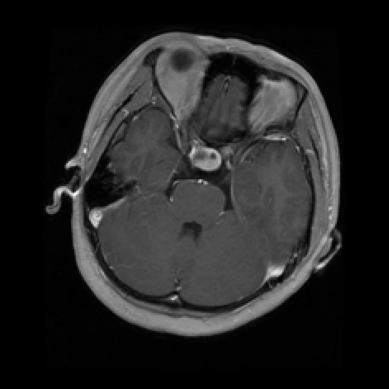

In [98]:
print(X_train.shape, X_train.dtype)                 # (5600, 224, 224) float32
print(X_train.min(), X_train.max())                 # 0.0 1.0
print(pd.Series(y_train).value_counts())            # 1400 each
plt.imshow(X_train[0], cmap="gray")                 # looks like a brain
plt.axis("off")